In [2]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import tensorflow.keras.backend as K

# 1: load the chronologically partitioned and scaled datasets for Agus II
data_dir = 'Model_Ready_Data_Agus2'

df_train = pd.read_csv(os.path.join(data_dir, 'Train.csv'), index_col='Time', parse_dates=True, dayfirst=False)
df_val = pd.read_csv(os.path.join(data_dir, 'Validation.csv'), index_col='Time', parse_dates=True, dayfirst=False)
df_calib = pd.read_csv(os.path.join(data_dir, 'Calibration.csv'), index_col='Time', parse_dates=True, dayfirst=False)
df_test = pd.read_csv(os.path.join(data_dir, 'Test.csv'), index_col='Time', parse_dates=True, dayfirst=False)

target_col_name = 'Total_Power' 
target_idx = df_train.columns.get_loc(target_col_name)

# 2: define the sliding window function to generate temporal sequence
def create_sequences(data, target_index, lookback, horizon=1):
    X, y = [], []
    data_array = data.values 
    for i in range(len(data_array) - lookback - horizon + 1):
        X_seq = data_array[i : (i + lookback), :]
        y_target = data_array[i + lookback + horizon - 1, target_index]
        X.append(X_seq)
        y.append(y_target)
    return np.array(X), np.array(y)

LOOKBACK = 96  # 24 hours of memory
HORIZON = 1    # 15 mins into the future

X_train, y_train = create_sequences(df_train, target_idx, LOOKBACK, HORIZON)
X_val, y_val = create_sequences(df_val, target_idx, LOOKBACK, HORIZON)
X_calib, y_calib = create_sequences(df_calib, target_idx, LOOKBACK, HORIZON)
X_test, y_test = create_sequences(df_test, target_idx, LOOKBACK, HORIZON)

# 3: configure the custom dual-quantile pinball loss function
QUANTILES = [0.05, 0.95]

def pinball_loss(y_true, y_pred):
    y_true_expanded = tf.expand_dims(y_true, axis=-1)
    
    q_lower = QUANTILES[0]
    err_lower = y_true_expanded - y_pred[:, 0:1]
    loss_lower = K.maximum(q_lower * err_lower, (q_lower - 1) * err_lower)
    
    q_upper = QUANTILES[1]
    err_upper = y_true_expanded - y_pred[:, 1:2]
    loss_upper = K.maximum(q_upper * err_upper, (q_upper - 1) * err_upper)
    
    return K.mean(loss_lower + loss_upper)
    
# 4: construct the 2-stacked LSTM architecture
n_timesteps = X_train.shape[1] 
n_features = X_train.shape[2]

model = Sequential()
model.add(Input(shape=(n_timesteps, n_features)))

model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.2)) 

model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))

# 5: compile the model with exactly two output neurons for the upper and lower prediction bounds 
model.add(Dense(units=2))
model.compile(optimizer='adam', loss=pinball_loss)

model.summary()

TensorFlow Version: 2.20.0
Starting CQR Phase 2 for Agus 2: LSTM Sequence Generation and Architecture...

Creating sequences (Lookback: 96 steps)...

Building the CQR Neural Network...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                 │ (None, 96, 64)        │       18,176 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_2 (Dropout)           │ (None, 96, 64)        │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ lstm_3 (LSTM)                 │ (None, 32)            │       12,416 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_3 (Dropout)           │ (None, 32)            │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_1 (Dense)               │ (None, 2)             │           66 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 30,658 (119.76 KB)

 Trainable params: 30,658 (119.76 KB)

 Non-trainable params: 0 (0.00 B)

Starting CQR Model Training for Agus 2...
Epoch 1/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 81s 76ms/step - loss: 0.0401 - val_loss: 0.0282
Epoch 2/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 71s 72ms/step - loss: 0.0266 - val_loss: 0.0218
Epoch 3/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 73s 74ms/step - loss: 0.0233 - val_loss: 0.0200
Epoch 4/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 70s 72ms/step - loss: 0.0213 - val_loss: 0.0196
Epoch 5/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 71s 72ms/step - loss: 0.0205 - val_loss: 0.0184
Epoch 6/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 71s 72ms/step - loss: 0.0200 - val_loss: 0.0173
Epoch 7/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 72s 73ms/step - loss: 0.0197 - val_loss: 0.0175
Epoch 8/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 69s 70ms/step - loss: 0.0193 - val_loss: 0.0182
Epoch 9/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 83s 71ms/step - loss: 0.0191 - val_loss: 0.0188
Epoch 10/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 68s 70ms/step - loss: 0.0190 - val_loss: 0.0175
Epoch 11/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 71s 72ms/step - loss: 0.0187 - val_l

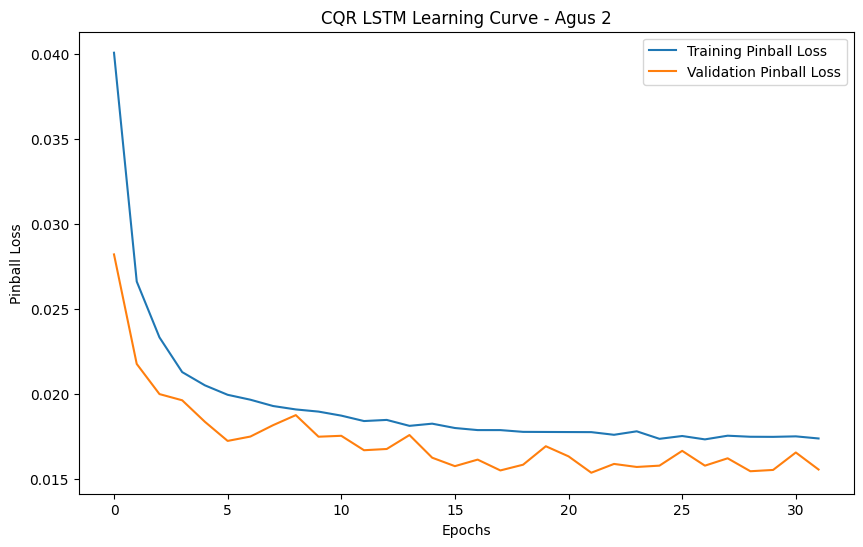

In [3]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 1: configure the early stopping mechanism to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 2: execute model training using the custom pinball loss function 
history = model.fit(
    X_train, y_train,
    epochs=50,          
    batch_size=32,      
    validation_data=(X_val, y_val), 
    callbacks=[early_stop],         
    verbose=1           
)

# 3: visualize the learning curve and export high-resolution figure
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Pinball Loss')
plt.plot(history.history['val_loss'], label='Validation Pinball Loss')
plt.title('CQR LSTM Learning Curve - Agus 2')
plt.xlabel('Epochs')
plt.ylabel('Pinball Loss')
plt.legend()
plt.savefig('Agus2_CQR_Learning_Curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd

# 1: reconstruct the robust scaler using strictly the training partition for Agus II
original_df = pd.read_csv('Processed_Agus2_Dataset.csv', index_col='Time', parse_dates=True, dayfirst=False)
features = original_df.columns.tolist()
train_end = int(len(original_df) * 0.60)

scaler = RobustScaler()
scaler.fit(original_df.iloc[:train_end][features])

# 2: execute model interface to generate raw dual-quantile predictions
calib_preds = model.predict(X_calib) # Outputs [Lower_Quantile, Upper_Quantile]
test_preds = model.predict(X_test)

# 3: define function to inverse transform the normalized quantiles and calculate the median point prediction
def unscale_cqr(preds, actuals):
    dummy_act = np.zeros((len(actuals), len(features)))
    dummy_lower = np.zeros((len(preds), len(features)))
    dummy_upper = np.zeros((len(preds), len(features)))

    dummy_act[:, 0] = actuals
    dummy_lower[:, 0] = preds[:, 0] # Neuron 0 (5th percentile)
    dummy_upper[:, 0] = preds[:, 1] # Neuron 1 (95th percentile)

    real_act = scaler.inverse_transform(dummy_act)[:, 0]
    real_low = scaler.inverse_transform(dummy_lower)[:, 0]
    real_up = scaler.inverse_transform(dummy_upper)[:, 0]
    
    real_median = (real_low + real_up) / 2.0
    
    return real_act, real_low, real_up, real_median

real_y_calib, real_low_calib, real_up_calib, real_med_calib = unscale_cqr(calib_preds, y_calib)
real_y_test, real_low_test, real_up_test, real_med_test = unscale_cqr(test_preds, y_test)

# 4: align results with chronological timestamps and export raw bounds for Phase 3 calibration
dates_calib = df_calib.index[LOOKBACK + HORIZON - 1:]
dates_test = df_test.index[LOOKBACK + HORIZON - 1:]

calib_df = pd.DataFrame({
    'Time': dates_calib, 
    'Actual_MW': real_y_calib, 
    'CQR_Lower_MW': real_low_calib, 
    'CQR_Upper_MW': real_up_calib,
    'Point_Prediction_MW': real_med_calib
})
calib_df.to_csv('Agus2_CQR_Calib.csv', index=False)

test_df = pd.DataFrame({
    'Time': dates_test, 
    'Actual_MW': real_y_test, 
    'CQR_Lower_MW': real_low_test, 
    'CQR_Upper_MW': real_up_test,
    'Point_Prediction_MW': real_med_test
})
test_df.to_csv('Agus2_CQR_Test.csv', index=False)

Predicting and un-scaling CQR bounds back to Megawatts (MW)...
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step
SUCCESS! CQR calibration and test bounds safely saved for Agus 2.
